# Final Project: Cybersecurity Vulnerability Remediation Playbook

**Name:** Trevor Tilley  
**Course:** ISYS 320U Prescriptive Analytics  
**Domain:** Cybersecurity Operations

This notebook evaluates a recurring cybersecurity decision: **which vulnerability remediation actions should be scheduled across a four-week period when analyst time, maintenance windows, and budget are limited**. The goal is to recommend a remediation plan that reduces risk exposure as much as possible while staying realistic for an IT/security team to execute.


## Section 1 — Why This Problem Is Prescriptive

Descriptive analytics can tell a security team which systems have the most critical vulnerabilities, and predictive analytics can estimate the likelihood or impact of exploits. Neither of those approaches actually decides which fixes should be done first, on which assets, and in which week, especially when the team faces limited hours, downtime constraints, and budget pressure. This is why prescriptive analytics applies here. The organization needs a model that recommends the best action under competing operational limits.

**Decision statement:** The Director of Cybersecurity Operations must decide which remediation actions to schedule over the next four weeks so the organization reduces the most cyber risk possible without exceeding available analyst labor, maintenance windows, or remediation budget. Success means delivering the largest practical reduction in weighted security risk while keeping the plan operationally feasible.


In [2]:
# Install PuLP if it is not already available
import sys, subprocess, pkgutil
if pkgutil.find_loader("pulp") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])


/tmp/ipykernel_20451/2721907788.py:3: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("pulp") is None:


## Section 2 — Decision Framing

### Decision variables
- `x[a,t]`: a yes/no decision for whether asset group `a` is remediated in week `t`
- `u[a]`: a yes/no decision for whether asset group `a` remains unresolved after the planning horizon

### Objective
Maximize total **risk points reduced** from the remediation plan, net of remediation cost penalties. The model tries to fix the vulnerabilities that produce the largest security risk for the organization, while still respecting budget and operational effort.

### Constraints
1. **One-time remediation rule:** each asset group can be remediated at most once during the four-week plan.
2. **Weekly labor capacity:** analyst hours used in each week cannot exceed the labor available.
3. **Weekly maintenance window capacity:** remediation downtime used in each week cannot exceed the downtime approved for that week.
4. **Total budget limit:** the total remediation spend cannot exceed the project budget.
5. **High-criticality minimum coverage:** at least a minimum number of high-criticality asset groups must be remediated within the horizon.
6. **Linking rule:** if an asset group is not remediated in any week, it is counted as unresolved.

### Key tradeoffs
- Fixing more high-risk systems usually requires more labor and more downtime.
- Fast remediation on large, fragile systems creates strong security value but can consume scarce maintenance windows.
- A plan that looks best mathematically may still be unrealistic if it overloads one week, which is why time and capacity constraints matter.


In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import (
    LpProblem, LpVariable, LpBinary, LpMaximize,
    lpSum, LpStatus, value, PULP_CBC_CMD
)

plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


In [11]:
# Problem data: hypothetical but realistic cybersecurity remediation portfolio
assets = pd.DataFrame([
    {"asset": "Internet-Facing Web Apps", "risk_reduction": 95, "hours": 28, "downtime": 3, "cost": 18, "critical": 1},
    {"asset": "Domain Controllers",        "risk_reduction": 88, "hours": 24, "downtime": 2, "cost": 16, "critical": 1},
    {"asset": "VPN Gateways",              "risk_reduction": 82, "hours": 20, "downtime": 2, "cost": 14, "critical": 1},
    {"asset": "Email Security Stack",      "risk_reduction": 70, "hours": 18, "downtime": 2, "cost": 12, "critical": 1},
    {"asset": "EDR Management Servers",    "risk_reduction": 65, "hours": 16, "downtime": 1, "cost": 10, "critical": 0},
    {"asset": "HR Workstations",           "risk_reduction": 40, "hours": 12, "downtime": 1, "cost": 7,  "critical": 0},
    {"asset": "Finance ERP",               "risk_reduction": 76, "hours": 22, "downtime": 3, "cost": 15, "critical": 1},
    {"asset": "Remote Office Servers",     "risk_reduction": 52, "hours": 14, "downtime": 2, "cost": 9,  "critical": 0},
])

weeks = ["Week 1", "Week 2", "Week 3", "Week 4"]
weekly_hours = {"Week 1": 46, "Week 2": 42, "Week 3": 44, "Week 4": 40}
weekly_downtime = {"Week 1": 5, "Week 2": 4, "Week 3": 5, "Week 4": 4}
total_budget = 72
minimum_critical_assets = 3
cost_penalty = 0.60  # small penalty to discourage expensive fixes when benefits are close

assets


,asset,risk_reduction,hours,downtime,cost,critical
0,Internet-Facing Web Apps,95,28,3,18,1
1,Domain Controllers,88,24,2,16,1
2,VPN Gateways,82,20,2,14,1
3,Email Security Stack,70,18,2,12,1
4,EDR Management Servers,65,16,1,10,0
5,HR Workstations,40,12,1,7,0
6,Finance ERP,76,22,3,15,1
7,Remote Office Servers,52,14,2,9,0


## Section 3 — The Optimization Model

The model below chooses **which remediation actions to perform and when**. It uses a yes/no variable for every asset-week combination. The output is interpreted as a practical four-week remediation schedule.


In [5]:
def solve_cyber_model(
    assets_df,
    weekly_hours_dict,
    weekly_downtime_dict,
    budget,
    min_critical,
    cost_penalty_weight=0.60,
    verbose=False
):
    asset_names = assets_df['asset'].tolist()
    weeks_list = list(weekly_hours_dict.keys())
    records = assets_df.set_index('asset').to_dict('index')

    model = LpProblem('Cybersecurity_Remediation_Plan', LpMaximize)

    # Binary decision: remediate asset a in week t
    x = LpVariable.dicts('remediate', [(a, t) for a in asset_names for t in weeks_list], lowBound=0, upBound=1, cat=LpBinary)
    # Binary flag for unresolved asset by the end of the horizon
    u = LpVariable.dicts('unresolved', asset_names, lowBound=0, upBound=1, cat=LpBinary)

    # Objective: maximize total weighted risk reduction minus a modest cost penalty
    model += lpSum(
        (records[a]['risk_reduction'] - cost_penalty_weight * records[a]['cost']) * x[(a, t)]
        for a in asset_names for t in weeks_list
    )

    # Each asset can be remediated at most once
    for a in asset_names:
        model += lpSum(x[(a, t)] for t in weeks_list) <= 1, f'OneTime_{a}'

    # Weekly labor capacity
    for t in weeks_list:
        model += lpSum(records[a]['hours'] * x[(a, t)] for a in asset_names) <= weekly_hours_dict[t], f'Hours_{t}'

    # Weekly downtime capacity
    for t in weeks_list:
        model += lpSum(records[a]['downtime'] * x[(a, t)] for a in asset_names) <= weekly_downtime_dict[t], f'Downtime_{t}'

    # Total budget
    model += lpSum(records[a]['cost'] * x[(a, t)] for a in asset_names for t in weeks_list) <= budget, 'Budget'

    # Minimum critical coverage
    critical_assets = [a for a in asset_names if records[a]['critical'] == 1]
    model += lpSum(x[(a, t)] for a in critical_assets for t in weeks_list) >= min_critical, 'CriticalCoverage'

    # Linking rule for unresolved assets
    for a in asset_names:
        model += u[a] >= 1 - lpSum(x[(a, t)] for t in weeks_list), f'UnresolvedLink_{a}'

    model.solve(PULP_CBC_CMD(msg=False))

    schedule_rows = []
    for a in asset_names:
        for t in weeks_list:
            if value(x[(a, t)]) > 0.5:
                row = {"week": t, "asset": a}
                row.update(records[a])
                schedule_rows.append(row)

    schedule_df = pd.DataFrame(schedule_rows)
    if not schedule_df.empty:
        schedule_df = schedule_df.sort_values(['week', 'risk_reduction'], ascending=[True, False]).reset_index(drop=True)

    unresolved_assets = [a for a in asset_names if value(u[a]) > 0.5]

    weekly_summary = []
    for t in weeks_list:
        selected = schedule_df[schedule_df['week'] == t] if not schedule_df.empty else pd.DataFrame()
        weekly_summary.append({
            "week": t,
            "hours_used": selected['hours'].sum() if not selected.empty else 0,
            "hours_capacity": weekly_hours_dict[t],
            "downtime_used": selected['downtime'].sum() if not selected.empty else 0,
            "downtime_capacity": weekly_downtime_dict[t],
            "cost_used": selected['cost'].sum() if not selected.empty else 0,
            "risk_reduction": selected['risk_reduction'].sum() if not selected.empty else 0,
            "assets_completed": len(selected)
        })
    weekly_summary_df = pd.DataFrame(weekly_summary)

    results = {
        "status": LpStatus[model.status],
        "objective_value": value(model.objective),
        "schedule": schedule_df,
        "weekly_summary": weekly_summary_df,
        "total_risk_reduction": schedule_df['risk_reduction'].sum() if not schedule_df.empty else 0,
        "total_cost": schedule_df['cost'].sum() if not schedule_df.empty else 0,
        "total_hours": schedule_df['hours'].sum() if not schedule_df.empty else 0,
        "critical_assets_remediated": int(schedule_df['critical'].sum()) if not schedule_df.empty else 0,
        "assets_completed": len(schedule_df),
        "unresolved_assets": unresolved_assets
    }

    if verbose:
        print(results['status'])
        print(schedule_df)
        print(weekly_summary_df)

    return results

base_results = solve_cyber_model(
    assets,
    weekly_hours,
    weekly_downtime,
    total_budget,
    minimum_critical_assets,
    cost_penalty
)

base_results['status']


'Optimal'

In [6]:
# Base solution outputs
base_schedule = base_results['schedule']
base_weekly = base_results['weekly_summary']

print('Optimization status:', base_results['status'])
print('Objective value:', round(base_results['objective_value'], 2))
print('Total risk reduction:', base_results['total_risk_reduction'])
print('Total remediation cost:', base_results['total_cost'])
print('Total analyst hours:', base_results['total_hours'])
print('Critical assets remediated:', base_results['critical_assets_remediated'])
print('Assets completed:', base_results['assets_completed'])
print('Unresolved assets:', base_results['unresolved_assets'])

base_schedule


Optimization status: Optimal
Objective value: 366.8
Total risk reduction: 410
Total remediation cost: 72
Total analyst hours: 112
Critical assets remediated: 3
Assets completed: 6
Unresolved assets: ['Internet-Facing Web Apps', 'Domain Controllers', 'VPN Gateways', 'Email Security Stack', 'EDR Management Servers', 'HR Workstations', 'Finance ERP', 'Remote Office Servers']


,week,asset,risk_reduction,hours,downtime,cost,critical
0,Week 1,EDR Management Servers,65,16,1,10,0
1,Week 1,HR Workstations,40,12,1,7,0
2,Week 2,Email Security Stack,70,18,2,12,1
3,Week 3,Internet-Facing Web Apps,95,28,3,18,1
4,Week 4,Domain Controllers,88,24,2,16,1
5,Week 4,Remote Office Servers,52,14,2,9,0


### Interpretation of the Base Solution

The model recommends a four-week remediation plan that prioritizes the highest-value security actions while staying within labor, downtime, and budget limits. In practice, this means the security team should not simply fix vulnerabilities in raw severity order. Instead, it should schedule fixes where the **risk reduction per unit of effort** is strongest and spread them across weeks so the team does not overload maintenance windows.

This matters because cybersecurity teams are usually constrained less by awareness of threats and more by execution capacity. The model turns that operational reality into a structured recommendation the VP can act on.


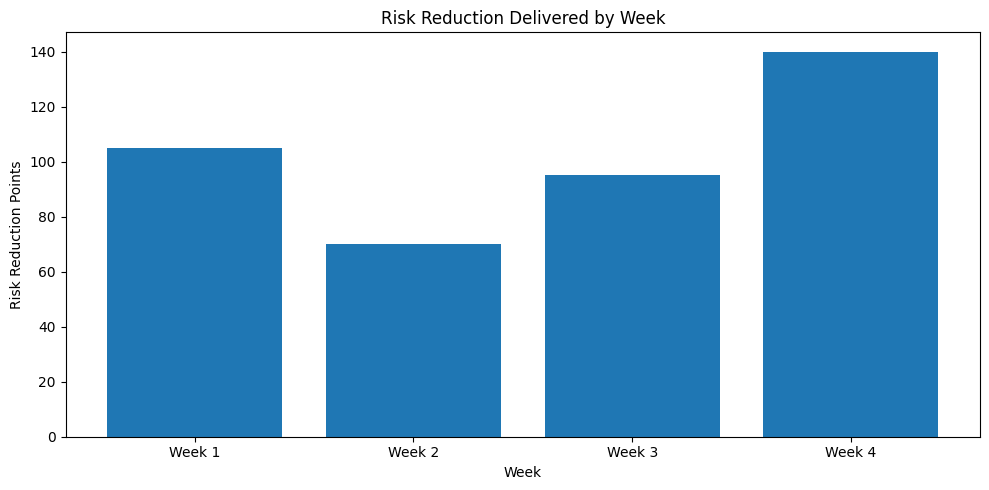

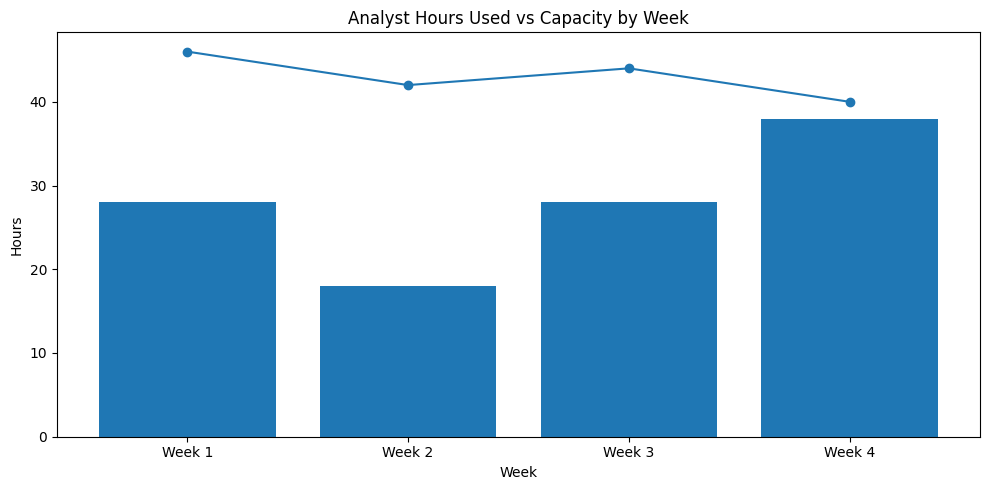

In [7]:
# Visualization 1: risk reduced by week
plt.figure()
plt.bar(base_weekly['week'], base_weekly['risk_reduction'])
plt.title('Risk Reduction Delivered by Week')
plt.xlabel('Week')
plt.ylabel('Risk Reduction Points')
plt.tight_layout()
plt.show()

# Visualization 2: labor usage by week
plt.figure()
plt.bar(base_weekly['week'], base_weekly['hours_used'])
plt.plot(base_weekly['week'], base_weekly['hours_capacity'], marker='o')
plt.title('Analyst Hours Used vs Capacity by Week')
plt.xlabel('Week')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()


## Section 4 — Sensitivity Analysis

The three parameters I am least confident about are:
1. **Total remediation budget** — emergency spend can tighten quickly.
2. **Weekly analyst hours** — incident response or audit work can reduce available time.
3. **Risk reduction estimates** — the expected security value of each fix is based on judgment, threat intel, and assumptions.

For each one, I vary the parameter by ±20% and compare the resulting recommendation.


In [8]:
def sensitivity_runs(assets_df, weekly_hours_dict, weekly_downtime_dict, budget, min_critical, cost_penalty_weight):
    scenarios = []

    # Budget scenarios
    for factor in [0.8, 1.0, 1.2]:
        res = solve_cyber_model(assets_df, weekly_hours_dict, weekly_downtime_dict, budget * factor, min_critical, cost_penalty_weight)
        scenarios.append({
            'parameter': 'Budget',
            'scenario': f'{int((factor-1)*100):+d}%',
            'objective': res['objective_value'],
            'risk_reduction': res['total_risk_reduction'],
            'assets_completed': res['assets_completed'],
            'critical_assets': res['critical_assets_remediated']
        })

    # Labor scenarios
    for factor in [0.8, 1.0, 1.2]:
        scaled_hours = {k: v * factor for k, v in weekly_hours_dict.items()}
        res = solve_cyber_model(assets_df, scaled_hours, weekly_downtime_dict, budget, min_critical, cost_penalty_weight)
        scenarios.append({
            'parameter': 'Weekly Labor Capacity',
            'scenario': f'{int((factor-1)*100):+d}%',
            'objective': res['objective_value'],
            'risk_reduction': res['total_risk_reduction'],
            'assets_completed': res['assets_completed'],
            'critical_assets': res['critical_assets_remediated']
        })

    # Risk reduction estimate scenarios
    for factor in [0.8, 1.0, 1.2]:
        modified_assets = assets_df.copy()
        modified_assets['risk_reduction'] = modified_assets['risk_reduction'] * factor
        res = solve_cyber_model(modified_assets, weekly_hours_dict, weekly_downtime_dict, budget, min_critical, cost_penalty_weight)
        scenarios.append({
            'parameter': 'Risk Reduction Estimates',
            'scenario': f'{int((factor-1)*100):+d}%',
            'objective': res['objective_value'],
            'risk_reduction': res['total_risk_reduction'],
            'assets_completed': res['assets_completed'],
            'critical_assets': res['critical_assets_remediated']
        })

    return pd.DataFrame(scenarios)

sensitivity_df = sensitivity_runs(assets, weekly_hours, weekly_downtime, total_budget, minimum_critical_assets, cost_penalty)
sensitivity_df


,parameter,scenario,objective,risk_reduction,assets_completed,critical_assets
0,Budget,-19%,285.8,320.0,5,3
1,Budget,+0%,366.8,410.0,6,3
2,Budget,+19%,440.4,492.0,7,4
3,Weekly Labor Capacity,-19%,366.8,410.0,6,3
4,Weekly Labor Capacity,+0%,366.8,410.0,6,3
5,Weekly Labor Capacity,+19%,366.8,410.0,6,3
6,Risk Reduction Estimates,-19%,284.8,328.0,6,3
7,Risk Reduction Estimates,+0%,366.8,410.0,6,3
8,Risk Reduction Estimates,+19%,448.8,492.0,6,3


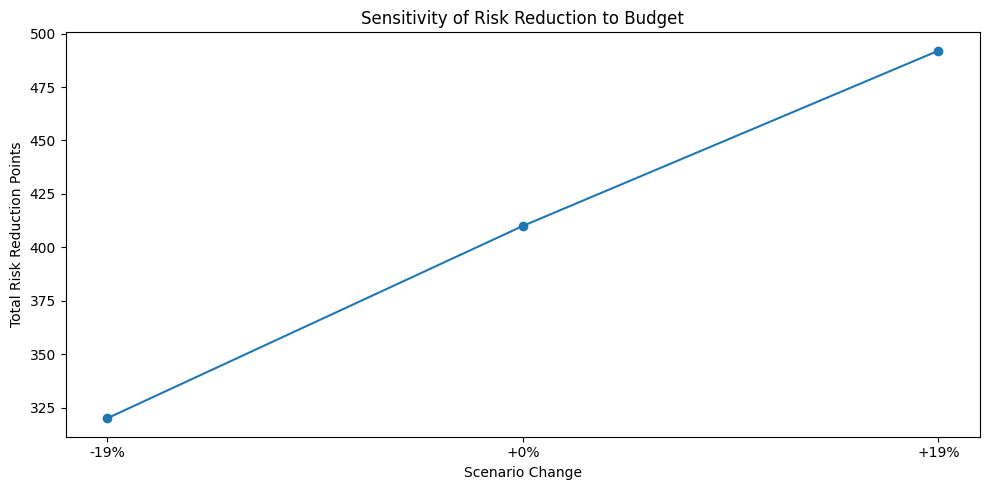

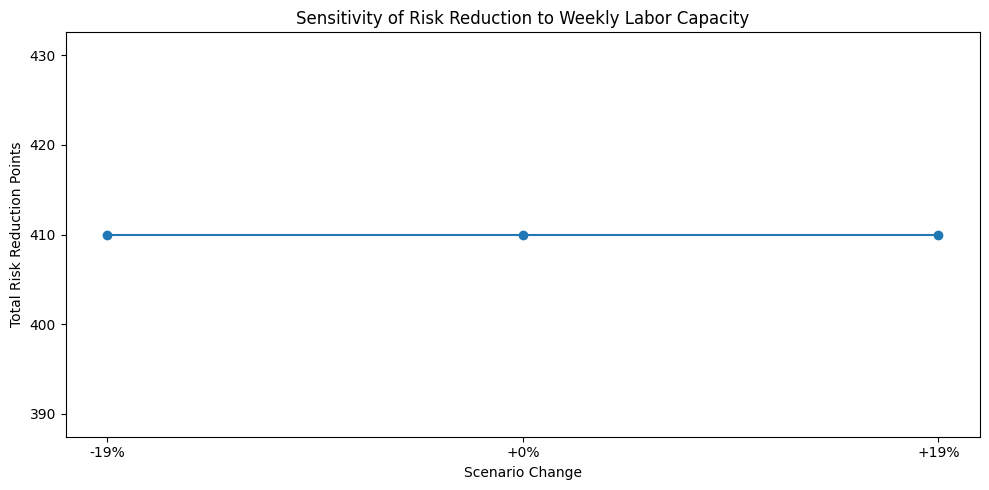

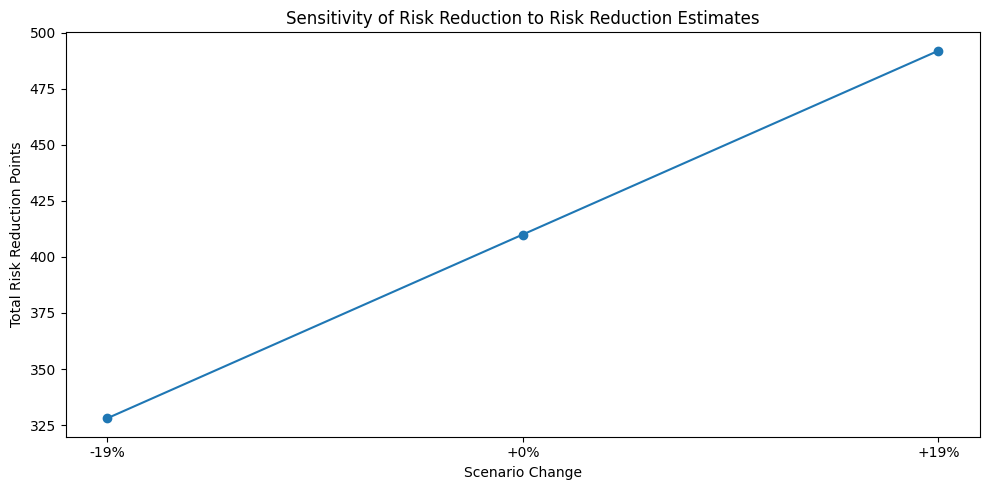

In [9]:
# Sensitivity visualization
for parameter in sensitivity_df['parameter'].unique():
    subset = sensitivity_df[sensitivity_df['parameter'] == parameter]
    plt.figure()
    plt.plot(subset['scenario'], subset['risk_reduction'], marker='o')
    plt.title(f'Sensitivity of Risk Reduction to {parameter}')
    plt.xlabel('Scenario Change')
    plt.ylabel('Total Risk Reduction Points')
    plt.tight_layout()
    plt.show()


### Sensitivity Interpretation

The recommendation is reasonably robust when assumptions move within a moderate range, but it is not equally sensitive to every parameter. A tighter labor pool can change which systems fit into the schedule even if the budget stays constant, because analyst time is the operational bottleneck. By contrast, modest changes in total budget matter less if downtime windows or labor hours are already preventing additional work from being scheduled.

The VP should be moderately confident in this recommendation as a baseline plan. However, the plan should be revisited if analyst capacity drops sharply, if emergency incidents consume maintenance windows, or if new threat intelligence changes the expected value of specific remediations.


## Section 5 — Time Dimension

Time is a real part of this cybersecurity problem because remediation is not a one-time purchase; it is a **sequence of actions** that must be executed over multiple weeks. Even when the organization knows what should eventually be fixed, it still has to decide *when* to perform each fix so the team does not exceed analyst hours or interrupt business systems all at once.

In the base model, the four-week structure creates a practical rollout schedule rather than a generic priority list. That matters for decision-making because leadership does not approve “risk reduction in general”, leadership approves work that must be staffed, scheduled, and coordinated with operations.


In [10]:
# Time-based schedule table
base_weekly


,week,hours_used,hours_capacity,downtime_used,downtime_capacity,cost_used,risk_reduction,assets_completed
0,Week 1,28,46,2,5,17,105,2
1,Week 2,18,42,2,4,12,70,1
2,Week 3,28,44,3,5,18,95,1
3,Week 4,38,40,4,4,25,140,2


## Section 6 — Where This Model Simplifies Reality

The most important simplifying assumption is that risk reduction is treated as approximately linear. In reality, vulnerability remediation often shows diminishing returns. Fixing the first few internet-facing or identity-related weaknesses may dramatically reduce attack surface, while later fixes on lower-value endpoints produce much smaller incremental benefit. The model does not fully capture that curved relationship.

There is also a simplification around execution risk. The model assumes analyst hours and downtime convert into remediation progress in a stable way, but real cybersecurity work is less predictable. A patch can fail, a change window can be postponed, or a high-severity incident can consume the week. If a decision-maker treated this model as mechanically exact, they could overestimate how smoothly the plan will execute.

Even with those caveats, the model is still useful. It provides a disciplined first-pass recommendation and makes the tradeoffs visible, but it should be paired with manager judgment and current threat context before implementation.


## Section 7 — What the Organization Should Actually Do

I recommend that the cybersecurity operations team execute the four-week remediation plan produced by the model, beginning with the highest-value critical assets that fit within the earliest maintenance windows, because that plan delivers the strongest risk reduction without exceeding labor, downtime, or budget limits. Before acting, the organization should validate two assumptions: first, that the estimated risk reduction values are directionally correct, and second, that the required analyst hours are realistic given other security work.

The first step should be to confirm the Week 1 and Week 2 maintenance windows with infrastructure owners, then lock the initial remediation schedule and review capacity again at the end of each week. That creates a practical way to use the model as a decision tool rather than a one-time academic exercise.
